<a href="https://colab.research.google.com/github/marianamalagon11/PTIA_LAB2_RN/blob/main/RN_lab_ignaciocastillo_marianamalagon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ESCUELA COLOMBIANA DE INGENIERÍA
# PRINCIPIOS Y TECNOLOGÍAS IA 2026-1
## REDES NEURONALES
## LABORATORIO 1/4

**NOMBRES:**
1. Ignacio Castillo

2. Mariana Malagón

**OBJETIVOS**

Desarrollar competencias básicas para:
1. Modelar y resolver problemas usando redes neuronales
2. Implementar los algoritmos hacia adelante (FEED-FORWARD) y hacia atrás con  aprendizaje (BACKPROPAGATION)
3. Apropiar un framework para redes neuronales (*keras*)

**ENTREGABLE**


*Reglas para el envío de los entregables*:

* **Forma de envío:**
Esta tarea se debe enviar únicamente a través de la plataforma Moodle en la actividad definida. Se tendrán dos entregas: inicial y final.

* **Formato de los archivos:**
***El entregable debe ser unicamente este archivo ".ipynb".*** Descargar como copia y cambiar la nomenclatura. No se permiten enlaces a colab

* **Nomenclatura para nombrar los archivos:**
El archivo deberá ser renombrado, “RN-lab-” seguido por los usuarios institucionales de los autores ordenados alfabéticamente (por ejemplo, se debe adicionar pedroperez al nombre del archivo, si el correo electrónico de Pedro Pérez es pedro.perez@mail.escuelaing.edu.co)




# PARTE I. IMPLEMENTACIÓN DE RED NEURONAL

Para este apartado se va a implementar una red neuronal con algoritmo de aprendizaje, en este caso propagación hacia atras del error.

*Introducido en la década de 1960 y popularizado casi 30 años después (1989) por Rumelhart, Hinton y Williams en el artículo titulado «Learning representations by back-propagating errors».*

## IMPLEMENTACIÓN DE RED NEURONAL CON PROPAGACIÓN HACIA ATRÁS

Implementar una red neuronal totalmente conectada desde su definición simple; calculando una salida $\check{Y} (Yp)$ para unas entradas $X$.

**Propiedades y parámetros:**

*   Tarea: **Clasificación multiple**
*   Tipo de capas: **Densas**
*   Métrica para evaluación : **ACCURACY**

<div>
<img src="https://cdn.prod.website-files.com/660ef16a9e0687d9cc27474a/662c426738658d748af1b20d_644af5900694f1102fb9b470_classification_guide_apc05.png" width="350"/>
</div>

> **Funciones de activación**

*   Función de activación en *Capas ocultas* : **ReLU**

<div>
<img src="https://intuitivetutorial.com/wp-content/uploads/2023/07/ReLU-1.png" width="350"/>
</div>

*   Función de activación en *Capa de salida* : **Sigmoide**

<div>
<img src="https://doimages.nyc3.cdn.digitaloceanspaces.com/010AI-ML/content/images/2018/06/sigm.png" width="350"/>
</div>

> **Funcion de costo**

*   Función de costo/perdida «error»: **Entropia Cruzada «Cross-Entropy»**

<div>
<img src="https://framerusercontent.com/images/jiDTkbQC7DPO2z2XmxqoeMsrkA.webp?width=1300&height=508" width="450"/>
</div>







## Paso 1. Derivadas

*Incluya en este apartado el proceso de la derivación de las funciones*

---
**Derivada función Sigmoide:**

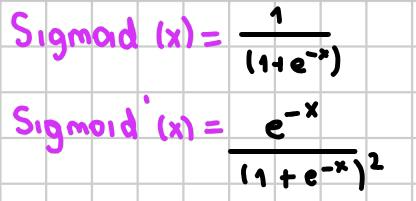


---
**Derivada función ReLU**

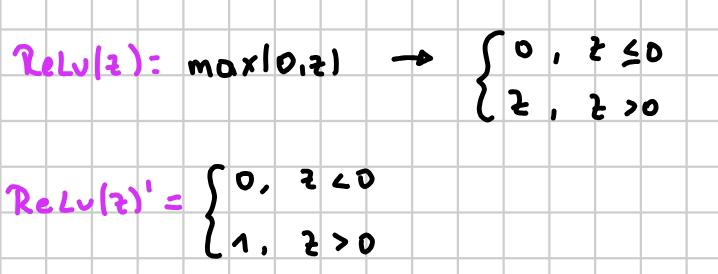

---
**Derivada función de costo: Entropia Cruzada**

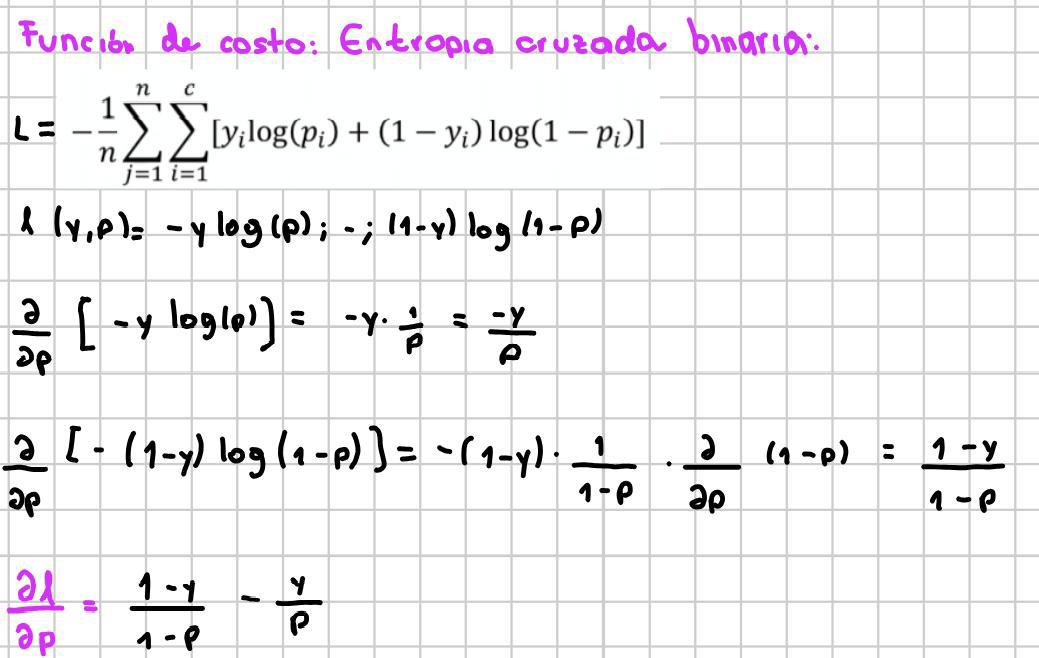


## Paso 2. Implementación del código para ANN (Dense)

### LIBRERÍA NECESARIA

In [1]:
import numpy as np
from abc import ABC, abstractmethod

### FUNCIONES DE BASE: MÉTRICA, COSTO Y ACTIVACIÓN

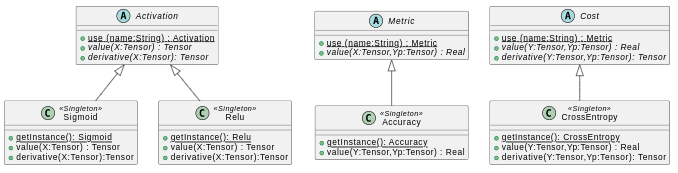

###MÉTRICA

In [3]:
class Metric(ABC):
    """ Abstracta: define entradas, salidas y el comportamiento inicial de los métodos clave para cualquier metrica """

    def use(self, name: str) -> "Metric":
        """ obtiene metrica (OBJ) a partir del nombre """
        name = name.lower().strip()
        if name in ["accuracy", "acc", "exactitud"]:
            return Accuracy()
        raise ValueError(f"Métrica no soportada: {name}")

    def value(self, Y: np.ndarray, Yp: np.ndarray):
        """ computa el desempeño (accuracy) de la red (> 0.6 es 1) """
        raise NotImplementedError("Metric.value debe ser implementado")


In [4]:
# Documentar los métodos implementados
class Accuracy(Metric):
    """ Metrica de exactitud (acertados / totales). Implementa Metric """

    def Accuracy(self):
        pass

    def value(self, Y: np.ndarray, Yp: np.ndarray) -> np.ndarray:
        Y = np.asarray(Y).reshape(-1)
        Yp = np.asarray(Yp).reshape(-1)

        Yp_class = (Yp > 0.6).astype(int)


        Y_class = (Y > 0.5).astype(int)

        return float(np.mean(Yp_class == Y_class))

In [8]:
# Adicione los casos de prueba de los métodos implementados

# Caso 1: todos correctos con umbral > 0.6
metric = Metric().use("accuracy")

Y  = np.array([0, 1, 1, 0])
Yp = np.array([0.1, 0.9, 0.61, 0.2])   # -> [0,1,1,0]
print("Accuracy caso 1 (esperado 1.0):", metric.value(Y, Yp))

# Caso 2: prueba exacta del borde (0.6 NO cuenta como 1)
Y  = np.array([0, 1, 1, 0])
Yp = np.array([0.6, 0.6000001, 0.59, 0.2])  # -> [0,1,0,0]
# aciertos: pos0 ok (0), pos1 ok (1), pos2 mal (esperado 1), pos3 ok (0) => 3/4 = 0.75
print("Accuracy caso 2 (esperado 0.75):", metric.value(Y, Yp))

# Caso 3: entradas como columna (n,1)
Y  = np.array([[0],[1],[0],[1]])
Yp = np.array([[0.2],[0.7],[0.8],[0.65]])   # -> [0,1,1,1] => aciertos: 3/4 = 0.75
print("Accuracy caso 3 (esperado 0.75):", metric.value(Y, Yp))

Accuracy caso 1 (esperado 1.0): 1.0
Accuracy caso 2 (esperado 0.75): 0.75
Accuracy caso 3 (esperado 0.75): 0.75


###COSTO

In [5]:
class Cost(ABC):
    """ Abstracta: define entradas, salidas y el comportamiento inicial de los métodos clave para cualquier función de costo """

    def use(self, name: str) -> "Cost":
        """ obtiene función de costo (OBJ) a partir del nombre """
        name = name.lower().strip()
        if name in ["crossentropy", "cross-entropy", "entropia", "entropia cruzada", "ce", "bce"]:
            return CrossEntropy()
        raise ValueError(f"Función de costo no soportada: {name}")

    def value(self, Y: np.ndarray, Yp: np.ndarray) -> float:
        raise NotImplementedError("Cost.value debe ser implementado")

    def derivative(self, Y: np.ndarray, Yp: np.ndarray) -> np.ndarray:
        raise NotImplementedError("Cost.derivative debe ser implementado")

In [6]:
# Documentar los métodos implementados
class CrossEntropy(Cost):
    """ Función de costo Entropía Cruzada. Implementa Cost """

    def CrossEntropy(self):
        pass

    def value(self, Y: np.ndarray, Yp: np.ndarray) -> np.ndarray:
        Y = np.asarray(Y)
        Yp = np.asarray(Yp)

        eps = 1e-12
        Yp = np.clip(Yp, eps, 1.0 - eps)

        loss = -(Y * np.log(Yp) + (1.0 - Y) * np.log(1.0 - Yp))

        return float(np.mean(loss))

    def derivative(self, Y: np.ndarray, Yp: np.ndarray) -> np.ndarray:
        Y = np.asarray(Y)
        Yp = np.asarray(Yp)

        eps = 1e-12
        Yp = np.clip(Yp, eps, 1.0 - eps)

        dL_dp = (1.0 - Y) / (1.0 - Yp) - (Y / Yp)

        n = Y.shape[0] if Y.ndim > 0 else 1
        dL_dp = dL_dp / n

        return dL_dp

In [9]:
# Adicione los casos de prueba de los métodos implementados
cost = Cost().use("crossentropy")

# Caso 1: buenas predicciones -> loss baja
Y  = np.array([[0],[1],[1],[0]], dtype=float)
Yp = np.array([[0.01],[0.99],[0.90],[0.10]], dtype=float)
L1 = cost.value(Y, Yp)
d1 = cost.derivative(Y, Yp)
print("CE caso 1 (debe ser baja):", L1)
print("derivative shape:", d1.shape, " | finite:", np.isfinite(d1).all())

# Caso 2: malas predicciones con alta confianza -> loss alta
Y  = np.array([[0],[1]], dtype=float)
Yp = np.array([[0.99],[0.01]], dtype=float)
L2 = cost.value(Y, Yp)
d2 = cost.derivative(Y, Yp)
print("CE caso 2 (debe ser alta):", L2)
print("derivative shape:", d2.shape, " | finite:", np.isfinite(d2).all())

# Caso 3: valores extremos (0 o 1) para verificar el clip (no debe explotar)
Y  = np.array([[1],[0]], dtype=float)
Yp = np.array([[1.0],[0.0]], dtype=float)  # si no hay clip, log(0) revienta
L3 = cost.value(Y, Yp)
d3 = cost.derivative(Y, Yp)
print("CE caso 3 (debe ser finita por el clip):", L3)
print("derivative finite:", np.isfinite(d3).all())

CE caso 1 (debe ser baja): 0.05770542575566387
derivative shape: (4, 1)  | finite: True
CE caso 2 (debe ser alta): 4.605170185988091
derivative shape: (2, 1)  | finite: True
CE caso 3 (debe ser finita por el clip): 9.999778782803785e-13
derivative finite: True


###ACTIVACION

In [7]:
class Activation(ABC):
    """ Abstracta: define entradas, salidas y el comportamiento inicial de los métodos clave para cualquier función de activación """

    def use(self, name: str) -> "Activation":
        """ obtiene función de activación (OBJ) a partir del nombre """
        name = name.lower().strip()
        if name in ["sigmoid", "logistic"]:
            return Sigmoid()
        if name in ["relu"]:
            return Relu()
        raise ValueError(f"Función de activación no soportada: {name}")

    def value(self, X: np.ndarray) -> np.ndarray:
        raise NotImplementedError("Activation.value debe ser implementado")

    def derivative(self, X: np.ndarray) -> np.ndarray:
        raise NotImplementedError("Activation.derivative debe ser implementado")


In [10]:
# Documentar los métodos implementados
class Sigmoid(Activation):
    """ Función de activación sigmoide. Implementa Activación """

    def Sigmoid(self):
        pass

    def value(self, X: np.ndarray) -> np.ndarray:
        X = np.asarray(X, dtype=float)
        # estable numéricamente
        out = np.empty_like(X, dtype=float)
        pos = X >= 0
        neg = ~pos
        out[pos] = 1.0 / (1.0 + np.exp(-X[pos]))
        expx = np.exp(X[neg])
        out[neg] = expx / (1.0 + expx)
        return out

    def derivative(self, X: np.ndarray) -> np.ndarray:
        S = self.value(X)
        return S * (1.0 - S)

In [11]:
# Documentar los métodos implementados
class Relu(Activation):
    """ Función de activación RELU. Implementa Activación """

    def Relu(self):
        pass

    def value(self, X: np.ndarray) -> np.ndarray:
        X = np.asarray(X, dtype=float)
        return np.maximum(0.0, X)

    def derivative(self, X: np.ndarray) -> np.ndarray:
        X = np.asarray(X, dtype=float)
        return (X > 0.0).astype(float)

In [14]:
# Adicione los casos de prueba de los métodos implementados
import numpy as np

sig = Activation().use("sigmoid")
relu = Activation().use("relu")

X = np.array([[-2.0], [0.0], [2.0]])

# Sigmoid
S = sig.value(X)
dS = sig.derivative(X)
print("Sigmoid(X):\n", S)
print("Sigmoid'(X):\n", dS)
print("Sigmoid(0) esperado 0.5 ->", S[1].item())

# ReLU
R = relu.value(X)
dR = relu.derivative(X)
print("ReLU(X):\n", R)
print("ReLU'(X):\n", dR)

# chequeos rápidos
assert np.all(R[X <= 0] == 0), "ReLU debe dar 0 en X<=0"
assert dR[0].item() == 0.0 and dR[2].item() == 1.0, "ReLU' debe ser 0 en negativos y 1 en positivos"
assert np.isfinite(S).all() and np.isfinite(dS).all(), "Sigmoid no debe producir NaN/Inf"

Sigmoid(X):
 [[0.11920292]
 [0.5       ]
 [0.88079708]]
Sigmoid'(X):
 [[0.10499359]
 [0.25      ]
 [0.10499359]]
Sigmoid(0) esperado 0.5 -> 0.5
ReLU(X):
 [[0.]
 [0.]
 [2.]]
ReLU'(X):
 [[0.]
 [0.]
 [1.]]


## RED NEURONAL TOTALMENTE CONECTADA «DENSE»

####Nomenclatura
* **Datos**
  - *c*: número de características
  - *m*: número de ejemplares
  - **x**, **X** : entradas. Un ejemplo (c) o todos los ejemplos (cxm)
  - **y**, **Y** : salidas reales. Un ejemplo (cx1) o todos los ejemplos(cxm)
  - **yp**, **Yp** : salidas estimadas. Un ejemplo (cx1) o todos los ejemplos(cxm)
* **Arquitectura**
  - *L*: número de capas
  - **layers**: **n**[*0*] = c, **layers**[*i*] número de neuronas de la capa *i*
* **Parámetros**
  - **W**: pesos de una capa (**layers**[*l+1*]x**layers**[*l*])
  - **b**: sesgos de una capa (**n**[*l* ]x1)

* **Gradientes**
  - **dW**: gradiente de **W**
  - **db**: gradiente de **b**

*Incluya en este apartado el proceso de la derivación de los gradientes*

---
**Gradiente dW**


---
**Graciente db**


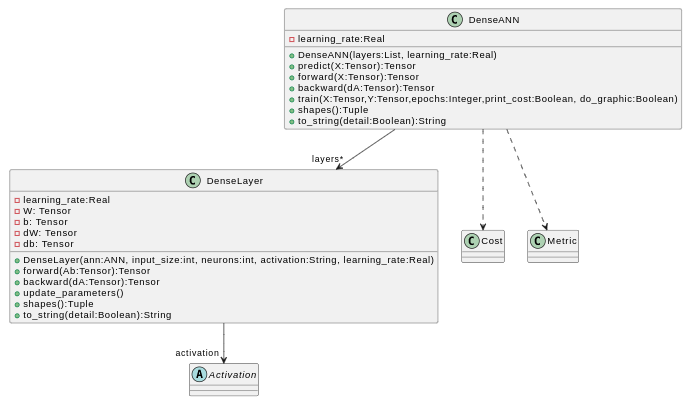

In [ ]:
class DenseANN:
  """ Representa una red neuronal totalmente conectada
  """
  def __init__(layers: list, learning_rate: float):
    """ inicializar las capas, luego almacenar la arquitectura de la red y la tasa de aprendizaje.
    Args:
      layers (list): número de -> caracteristicas de entrada (list[0]), neuronas en la capa oculta i, neuronas de salida (list[-1])
      learning_rate (float): eta tasa de aprendizaje de la red
    """
    self.learning_rate
    pass

  def predict(self, X: np.ndarray):
    """ computa valores de predicción a partir de las entradas
    Args:
      X (ndarray): valores de características (entradas)
    Return:
      Yp (ndarray): valores de salidas obtenidas
    """
    pass

  def forward(self, X: np.ndarray):
    """ computa hacia adelante un ciclo de entradas a traves de la red generando una predicción
    Args:
      X (ndarray): valores de características (entradas)
    Return:
      Yp (ndarray): valores de salidas obtenidas
    """
    pass


  def backward(self, dA: np.ndarray):
    """ computa hacia atras los errores y gradientes
    Args:
      dA (ndarray): valores del gradiente de predicción
    Return:
      G (ndarray): gradientes de la red
    """
    pass

  def train(self, X: np.ndarray, Y: np.ndarray, epochs: int, print_cost: bool, do_graphic: bool):
    """ entrenar red neuronal
    Args:
      X (ndarray): valores de características - conjunto de entrenamiento
      Y (ndarray): valores de salidas esperadas - conjunto de entrenamiento
      epochs (int): número de iteraciones
      print_cost (bool): mostrar el costo por iteración
      do_graphic (bool): graficar el costo por iteración
    """
    pass

  def shapes():
    """ genera los valores asociados al tamaño de la red
    Return:
      s (tupla<int>): tamaño de la red
    """
    pass

  def to_string():
    """
    """
    pass

## CAPA CON PERCEPTRONES

In [ ]:
class DenseLayer:
  """ Representa una capa (oculta o salida) en la red neuronal
  """
  def __init__(self, input_size: int, neurons: int, activation: str, learning_rate: float):
    """ inicializar una capa de neuronas dentro de la red neuronal.
    Args:
      input_size (int): número de neuronas de capa anterior o de atributos de entrada
      neurons (int): número de neuronas en la capa
      activation (str): nombre de la función de activación
      learning_rate (float): eta tasa de aprendizaje de la red
    """
    self.learninig_rate
    self.W
    self.b
    self.dW
    self.db
    pass

  def forward(self, Ab: np.ndarray):
    """ Transmite la entrada a partir del acumulativo de señales (f_base) y el potencial eléctrico (f_activación).
    Args:
      Ab (np.ndarray): características ó valores de activación de la capa anterior
    Return:
      S (np.ndarray): valores de activación de neuronas
    """
    pass

  def backward(self, Ab: np.ndarray):
    """ Transmite hacia atras el cambio del grandiente y el error (delta)
    Args:
      Ab (np.ndarray): características ó valores de error de la capa siguiente
      [capa salida] valores etiquetados esperados | [capa oculta] delta capa siguiente
    Return:
      S (np.ndarray): valor delta considerando gradiente y error
    """
    pass

  def update_parameters(self):
    """ Actualiza los parámetros de la capa a partir del gradiente y el error.
    Return:
    """
    pass

  def shapes(self):
    """ genera los valores asociados al tamaño de la capa
    Return:
      s (tupla<int>): tamaño de la capa
    """
    pass

  def to_string(self, detail: bool):
    """
    """
    pass

In [ ]:
# Como primer caso de prueba entrene un perceptrón para calcular el operador lógico and. Explique los resultados.

In [ ]:
# Como segundo caso de prueba entrene un perceptrón para calcular el operador lógico or. Explique los resultados.

In [ ]:
# Como tercer caso de prueba entrene un perceptrón para calcular el operador lógico xor. Explique los resultados.

In [ ]:
# Como cuarto caso de prueba entrene un perceptrón multicapa [2,2,1] para calcular el operador lógico xor. Explique los resultados

In [ ]:
# Como último caso de prueba entrene una red para el dataset propuesto por su profesor. Use 80% para entrenamiento y 20% para pruebas. Explique los resultado.

# PARTE 2. USO DE FRAMEWORK PARA REDES NEURONALES

Para este apartado se va a hacer uso de una librería que brinda de manera simplificada un entrenamiento flexible de distintas redes neuronales. En este caso será **Keras**

> Keras proporciona una interfaz Python simplificada para TensorFlow y se ha convertido en uno de los framework más usados en redes neuronales; especialmente las profundas. Cualquier código Keras que escribas se ejecuta en en TensorFlow (también se pueden utilizar CNTK y Theano como *back-end*, pero el desarrollo de estos se ha detenido).

Keras ofrece dos API: una [API secuencial](https://keras.io/guides/sequential_model/) y una [API funcional](https://keras.io/guides/functional_api/). La primera es más sencilla y resulta suficiente para la mayoría de las redes neuronales. La segunda es útil en escenarios  como redes con topologías no secuenciales o de capas compartidas. En nuestro caso usaremos el API secuencial.

---
Resuelvan un problema de clasificación usando el *dataset* definido por su profesor. (70% entrenamiento, 10% validación y 20% pruebas)

##Paso 1: Definir el problema
Antes de desarrollar un modelo, es fundamental establecer qué se quiere lograr y cómo se medirá el éxito. Esto implica explicar el problema, elegir una métrica adeucada y establecer un umbral de desempeño.


*Incluyan la respuesta*

##Paso 2: Explorar y preparar los datos
Para comprender la neturaleza de los datos que estamos utilizando es necesario **explorar** el *dataset* con visualizaciones adecuadas que permitan conocer la distribución de clases o valores, la presencia de valores nulos o atípicos y las correlaciones entre variables.

**Preparar** los datos para que la red pueda aprender de manera eficiente implica, entre otras cosas, la limpieza de datos, la normalización o estandarización de valores, la codificación de variables categóricas y la separación en conjuntos de entrenamiento (train), validación (dev) y prueba (test).

In [ ]:
#Analizar los datos

*Incluyan observaciones**

In [ ]:
#Preparar los datos separandolos en entrenamiento, validación y pruebas.

##Paso 3: Desarrollar la red

### Paso 3.1: Definir el modelo Keras

Crear una red neuronal utilizando la API secuencial de Keras es sencillo.

1. Se crea una instancia de la clase Sequential.
2. Se llama a *add* en el objeto *Sequential* para añadir capas. Las capas en sí mismas son instancias de clases como Dense, que representa una capa totalmente conectada con un número específico de neuronas que utilizan una función de activación específica.

In [ ]:
# Inicializar modelo Sequencial()
# Añadir capas de la clase Dense: .add(Dense(...))

### Paso 3.2: Compilar el modelo Keras

Una vez inicializado el modelo, hay que compilarlo. Para esto hay que definir las propiedades adicionales necesarias para entrenar la red.

Se debe especificar minimamente:
1. la **función de pérdida** que se utilizará para evaluar un conjunto de pesos
2. el **optimizador** utilizado para buscar diferentes pesos para la red, que en la versión clásica se usa el *gradiente descendente*, pero existen otros famosos como *ADAM*
3. la **métrica** que se desea reportar durante el entrenamiento.

In [ ]:
#Compilar el modelo

### Paso 3.3: Entrenar (Fit) el modelo Keras

Una vez compilado, es el momento de entrenar o ajustar el modelo con algunos datos. Para esto se hace llamando al método ***fit()*** del modelo.

Tenga en cuenta que el entrenamiento se realiza por épocas (*epoch*), y cada época se divide en lotes (*batch*).

1. **Epoch:** un ciclo/pasada por todas las observaciones del conjunto de datos de entrenamiento.
2. **Batch:** un ciclo de una o más observaciones en un *epoch* antes de que se actualicen los pesos.

In [ ]:
#Entrenar el modelo

### Paso 3.4: Evaluar el modelo Keras

Ya entrenada la red neuronal con todo el conjunto de datos de entrenamiento, se puede evaluar su rendimiento con otra serie de datos.

Para evaluar el modelo se puede hacer uso del método ***evaluate()*** agregandole los respectivos conjuntos de datos con su la salida esperada.

In [ ]:
#Evaluar el modelo

##Paso 4: Redactar conclusiones

*Incluyan las conclusiones*

## RETROSPECTIVA

**1.** ¿Cuál fue el tiempo total invertido en el laboratorio por cada uno de ustedes? (Horas/Hombre)

**2.** ¿Cuál es el estado actual del laboratorio? ¿Por qué?

**3.** ¿Cuál consideran fue el mayor logro? ¿Por qué?

**4.** ¿Cuál consideran que fue el mayor problema técnico? ¿Qué hicieron para resolverlo?

**5.** ¿Qué hicieron bien como equipo? ¿Qué se comprometen a hacer para mejorar los resultados?

**6**.¿Qué referencias usaron? ¿Cuál fue la más útil? Incluya citas con los estándares adecuados.

*Incluyan las respuesta*